In [1]:
import json
import sys
from collections import defaultdict
from itertools import combinations
from pathlib import Path
import itertools
import numpy as np
import os

import torch
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns


/home/alexpv/anaconda3/envs/tc_clip/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MANIFOLDS = [
    "euclidean", # raw embeddings normalized to lie on the unit sphere, dimension d
    # "lorentz_0.1_exp0", # raw embeddings projected to the Lorentz model using the exponential map at the origin, dimension d+1 (requires 0 padding)
    "lorentz_0.2_exp0",
    "lorentz_0.5_exp0",
    "lorentz_1_exp0",
    # "lorentz_2_exp0",
    # "lorentz_2.5_exp0",
    # "lorentz_5_exp0",
]

In [3]:
all_dirs = [
    "/home/alexpv/Default_Folder/notes/phd/1-projects/data_upload/slot_extractions_slotconstrast_dinov2",
    "/home/alexpv/Default_Folder/notes/phd/1-projects/data_upload/slot_extractions_spot_coco",
    "/home/alexpv/Default_Folder/notes/phd/1-projects/data_upload/slot_extractions_videosaur_dinov1",
    "/home/alexpv/Default_Folder/notes/phd/1-projects/data_upload/slot_extractions_videosaur_dinov2"
]

In [4]:
data_dir = all_dirs[3]

In [5]:
def check_is_sphere(vectors):
    return torch.allclose(vectors.norm(dim=-1), torch.ones_like(vectors.norm(dim=-1)))

def check_is_lorentz(vectors, c=1.):
    inner_product = inner_lorentz(vectors, vectors)
    return torch.allclose(inner_product, -1./c * torch.ones_like(inner_product), atol=1e-5, rtol=1e-4)


In [6]:
def exp_map0(vectors, c=torch.tensor([1.])):
    # Exponential map at the origin for the Lorentz model
    # vectors: (batch_size, dim)
    # returns: (batch_size, dim+1)
    rc_norm = torch.sqrt(c) * vectors.norm(dim=-1, keepdim=True)
    time_component_at_origin = torch.sqrt(1./c)
    time_component = time_component_at_origin * torch.cosh(rc_norm)
    spacial_component = torch.sinh(rc_norm) * vectors / torch.clamp(rc_norm, min=1e-5)
    return torch.cat([time_component, spacial_component], dim=-1)
    
    
def inner_lorentz(x, y):
    # Inner product in the Lorentz model
    # x, y: (batch_size, dim+1)
    # returns: (batch_size,)
    return -x[..., 0] * y[..., 0] + torch.sum(x[..., 1:] * y[..., 1:], dim=-1)


def norm_lorentz(x, tol=1e-5):
    # Norm in the Lorentz model
    # x: (batch_size, dim+1)
    # returns: (batch_size,)
    return torch.sqrt(torch.clamp(torch.abs(inner_lorentz(x, x)), min=tol))


def projx_lorentz(x, c=1.):
    # Projection to the Lorentz model
    # x: (batch_size, dim)
    # returns: (batch_size, dim+1)
    rc_norm = torch.sqrt(c) * x.norm(dim=-1, keepdim=True)
    time_component = torch.sqrt(1./c + rc_norm**2)
    return torch.cat([time_component, x], dim=-1)


def get_origin_lorentz(dim, c=torch.tensor([1.]), dtype=torch.float32):
    time_component_at_origin = torch.sqrt(1./c)
    return torch.cat([time_component_at_origin * torch.ones(1, dtype=dtype), torch.zeros(dim-1, dtype=dtype)], dim=0)


def proj_to_tgz_lorentz(x, z, c=1.):
    # Projection of a point in space to the tangent space at the origin for the Lorentz model
    # x: (batch_size, dim)
    # returns: (batch_size, dim)
    return x + c * z * inner_lorentz(x, z).unsqueeze(-1)


def centroid_lorentz(points, c=1., tol=1e-5):
    # Compute the centroid of a set of points in the Lorentz model using standard mean
    # points: (num_points, dim+1)
    # returns: (dim+1,)
    mean = points.mean(dim=0)
    return mean / (norm_lorentz(mean, tol=tol) * torch.sqrt(c))


def distance_lorentz(x, y, c=1.0, eps=1e-7):
    # Distance in the Lorentz model
    # x, y: (batch_size, dim+1)
    inner_prod = inner_lorentz(x, y)
    z = -inner_prod * c
    z = torch.clamp(z, min=1.0 + eps)
    return torch.acosh(z) / torch.sqrt(torch.tensor(c, dtype=x.dtype, device=x.device))


def distance_norm_lorentz(x, y, c=1.):
    # Distance in the Lorentz model using the norm of the difference
    # x, y: (batch_size, dim+1)
    # returns: (batch_size,)
    diff = x - y
    return norm_lorentz(diff)

In [7]:
def stereographic_proj(x):
    # Stereographic projection to the sphere
    # x: (batch_size, dim)
    # returns: (batch_size, dim+1)
    norm_sq = x.norm(dim=-1, keepdim=True)**2
    time_component = (norm_sq - 1) / (norm_sq + 1)
    spacial_component = 2 * x / (norm_sq + 1)
    return torch.cat([time_component, spacial_component], dim=-1)

def distance_sphere(x, y):
    # Distance on the sphere with cosine similarity
    # x, y: (batch_size, dim+1)
    # returns: (batch_size,)
    inner_prod = torch.sum(x * y, dim=-1)
    return torch.acos(inner_prod.clamp(-1 + 1e-7, 1 - 1e-7))

In [8]:
def pairwise_dist(vectors, manifold_name):
    """Compute (N, N) geodesic distance matrix.

    Args:
        vectors: (N, D)
        manifold_name: one of MANIFOLDS.

    Returns:
        (N, N) distance tensor.
    """
    if manifold_name.startswith("lorentz"):
        c = float(manifold_name.split("_")[1])
        # Lorentz inner: -x0*y0 + x_rest @ y_rest^T → (P, C)
        inner = -vectors[:, 0:1] @ vectors[:, 0:1].T + vectors[:, 1:] @ vectors[:, 1:].T
        return torch.acosh((-inner * c).clamp(min=1.0)) / np.sqrt(c)
    else:
        norms = vectors.norm(dim=1, keepdim=True)
        cos_sim = vectors @ vectors.T / (norms @ norms.T)
        return torch.acos(cos_sim.clamp(-1 + 1e-7, 1 - 1e-7))

def distance(x, y, manifold_name, c=None):
    if manifold_name.startswith("lorentz"):
        c = torch.tensor(float(manifold_name.split("_")[1]), dtype=vectors.dtype)
        return distance_lorentz(x, y, c)
    else:
        return distance_sphere(x / x.norm(dim = 1, keepdim=True), y / y.norm())

In [9]:
def compute_centroid(vectors, manifold_name):
    """Manifold-appropriate centroid for the synthetic root.

    Args:
        vectors: (N, D) tensor on the manifold.
        manifold_name: one of MANIFOLDS.

    Returns:
        (D,) centroid tensor.
    """
    if manifold_name.startswith("lorentz"):
        c = torch.tensor(float(manifold_name.split("_")[1]), dtype=vectors.dtype)
        return centroid_lorentz(vectors, c=c)
    else:
        return vectors.mean(dim=0)

In [10]:
def get_origin(dim, manifold_name):
    if manifold_name.startswith("lorentz"):
        c = torch.tensor(float(manifold_name.split("_")[1]))
        return get_origin_lorentz(dim, c=c)
    else:
        return torch.zeros(dim)

In [11]:
def project_to_manifold(vectors, manifold):
    vectors = vectors.to(torch.float64)
    if manifold == "euclidean":
        return vectors
    elif manifold == "sphere":
        vectors = vectors / torch.norm(vectors, dim=-1, keepdim=True)
        assert check_is_sphere(vectors), "Projection to sphere failed, not all vectors have norm 1"
        return vectors
    elif manifold.endswith("_exp0"):
        c = torch.tensor(float(manifold.split("_")[1]), dtype=vectors.dtype)
        vectors = exp_map0(vectors, c=c)
        assert check_is_lorentz(vectors, c=c), "Projection to Lorentz failed, not all vectors satisfy the Lorentz condition"
        return vectors
    elif manifold == "lorentz_1_projx":
        c = torch.tensor(float(manifold.split("_")[1]), dtype=vectors.dtype)
        vectors = projx_lorentz(vectors, c=c)
        assert check_is_lorentz(vectors, c=c), "Projection to Lorentz failed, not all vectors satisfy the Lorentz condition"
        return vectors
    elif manifold == "sphere_estereographic":
        vectors = stereographic_proj(vectors)
        assert check_is_sphere(vectors), "Projection to sphere failed, not all vectors have norm 1"
        return vectors
    elif manifold == "lorentz_1_exp0_restricted":
        c = torch.tensor(float(manifold.split("_")[1]), dtype=vectors.dtype)
        origin = get_origin_lorentz(vectors.shape[-1], c=c, dtype=vectors.dtype)
        proj_vectors = proj_to_tgz_lorentz(vectors, origin, c=c)
        assert torch.all(proj_vectors[:, 0] == 0), "Projection to tangent space at origin failed, time component is not 0"
        vectors = exp_map0(proj_vectors[:, 1:], c=c)
        assert check_is_lorentz(vectors, c=c), "Projection to Lorentz failed, not all vectors satisfy the Lorentz condition"
        return vectors
    elif manifold == "lorentz_1_projx_restricted":
        c = torch.tensor(float(manifold.split("_")[1]), dtype=vectors.dtype)
        vectors = projx_lorentz(vectors[:, 1:], c=c)
        assert check_is_lorentz(vectors, c=c), "Projection to Lorentz failed, not all vectors satisfy the Lorentz condition"
        return vectors

        
    else: 
        raise ValueError(f"Unknown manifold: {manifold}")
        

        

In [12]:
# for data_dir in all_dirs:
print(f"Processing directory: {data_dir}")
data_dir = Path(data_dir)

video_dirs = sorted(d for d in data_dir.iterdir() if d.is_dir() and (d.name.startswith("video_") or d.name.startswith("image_")))
print(f"Found {len(video_dirs)} instances in {data_dir}")

embeddings_info = defaultdict(dict)

for video_dir in tqdm(video_dirs, desc=f"Processing videos in {data_dir.name}"):
    # Take files of form slots_raw_*.pt
    all_slots = list(video_dir.glob("slots_raw_*.pt"))
    embeddings_info[video_dir.name] = defaultdict(dict)
    for slots in all_slots:
        # embeddings_info[video_dir.name][slots.stem] = defaultdict(dict)
        with open(slots, "rb") as f:
            data = torch.load(f)
            # Only keep the last frame if it is not coco
            if "coco" not in data_dir.stem:
                embeddings_info[video_dir.name]["raw"][slots.stem.split("_")[-1]] = data[-1]
            else:
                embeddings_info[video_dir.name]["raw"][slots.stem.split("_")[-1]] = data
        for manifold in MANIFOLDS:
            projected = project_to_manifold(
                embeddings_info[video_dir.name]["raw"][slots.stem.split("_")[-1]].to(torch.float64),
                manifold,
            )
            embeddings_info[video_dir.name][f"{manifold}"][slots.stem.split("_")[-1]] = projected


# Save the embeddings info to a .pt file
print(f"Saving embeddings info for {data_dir}...")
output_file = data_dir / "embeddings_info.pt"
with open(output_file, "wb") as f:
    torch.save(embeddings_info, f)

Processing directory: /home/alexpv/Default_Folder/notes/phd/1-projects/data_upload/slot_extractions_videosaur_dinov2
Found 300 instances in /home/alexpv/Default_Folder/notes/phd/1-projects/data_upload/slot_extractions_videosaur_dinov2


Processing videos in slot_extractions_videosaur_dinov2:   0%|          | 0/300 [00:00<?, ?it/s]

Processing videos in slot_extractions_videosaur_dinov2: 100%|██████████| 300/300 [00:00<00:00, 749.56it/s]


Saving embeddings info for /home/alexpv/Default_Folder/notes/phd/1-projects/data_upload/slot_extractions_videosaur_dinov2...


In [13]:
# Load the embeddings info from the .pt file
print(f"Loading embeddings info for {data_dir}...")
input_file = Path(data_dir) / "embeddings_info.pt"
with open(input_file, "rb") as f:
    embeddings_info = torch.load(f)

# Compute trees and distances for each video and each manifold
distances_info = defaultdict(dict)
for video_name, video_data in tqdm(embeddings_info.items(), desc=f"Processing videos in {data_dir} for distances"):
    distances_info[video_name] = defaultdict(dict)
    for manifold_name, manifold_data in video_data.items():
        if manifold_name == "raw":
            continue
        vectors_list = []
        for level in [3, 5, 7, 11, 13]:
            vectors_list.append(manifold_data[str(level)])

        vectors = torch.cat([v for v in vectors_list], dim = 0).to(dtype=torch.float64)

        groups = [(0,3), (3,8), (8,15), (15,26), (26,39)]
        # groups = [(0,3), (3,8), (8,15), (15,26)]

        all_means = torch.stack([
            compute_centroid(vectors[a:b], manifold_name)
            for a, b in groups
        ])

        dist_matrix = pairwise_dist(all_means, manifold_name)

        best_triplet = None
        best_score = float("inf")

        for combo in itertools.combinations(range(all_means.shape[0]), 3):
            i, j, k = combo
            
            # sum of pairwise distances inside the triplet
            score = dist_matrix[i, j] + dist_matrix[i, k] + dist_matrix[j, k]
            
            if score < best_score:
                best_score = score
                best_triplet = combo

        mean_vector = compute_centroid(all_means[list(best_triplet)], manifold_name)
        dists_mean = distance(all_means, mean_vector, manifold_name)
        dists = distance(vectors, mean_vector, manifold_name)

        origin = get_origin(mean_vector.shape[-1], manifold_name)
        if manifold_name == "euclidean":
            dists_origin_mean = all_means.norm(dim = -1)
            dists_origin = vectors.norm(dim = -1)
        else:
            dists_origin_mean = distance(all_means, origin, manifold_name)
            dists_origin = distance(vectors, origin, manifold_name)

        pseudo = all_means[0]
        dists_pseudo_mean = distance(all_means, pseudo, manifold_name)
        dists_pseudo = distance(vectors, pseudo, manifold_name)

        distances_info[video_name][manifold_name] = {
                "mean_vector": mean_vector,
                "best_triplet": best_triplet, 
                "dists_mean": dists_mean,
                "dists_origin_mean": dists_origin_mean,
                "dists_pseudo_mean": dists_pseudo_mean,
                "dists": dists,
                "dists_origin": dists_origin,
                "dists_pseudo": dists_pseudo,
                "dist_matrix": dist_matrix
            }

Loading embeddings info for /home/alexpv/Default_Folder/notes/phd/1-projects/data_upload/slot_extractions_videosaur_dinov2...


Processing videos in /home/alexpv/Default_Folder/notes/phd/1-projects/data_upload/slot_extractions_videosaur_dinov2 for distances:   0%|          | 0/300 [00:00<?, ?it/s]/tmp/ipykernel_320011/1785512819.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.acosh(z) / torch.sqrt(torch.tensor(c, dtype=x.dtype, device=x.device))
Processing videos in /home/alexpv/Default_Folder/notes/phd/1-projects/data_upload/slot_extractions_videosaur_dinov2 for distances: 100%|██████████| 300/300 [00:00<00:00, 1097.72it/s]


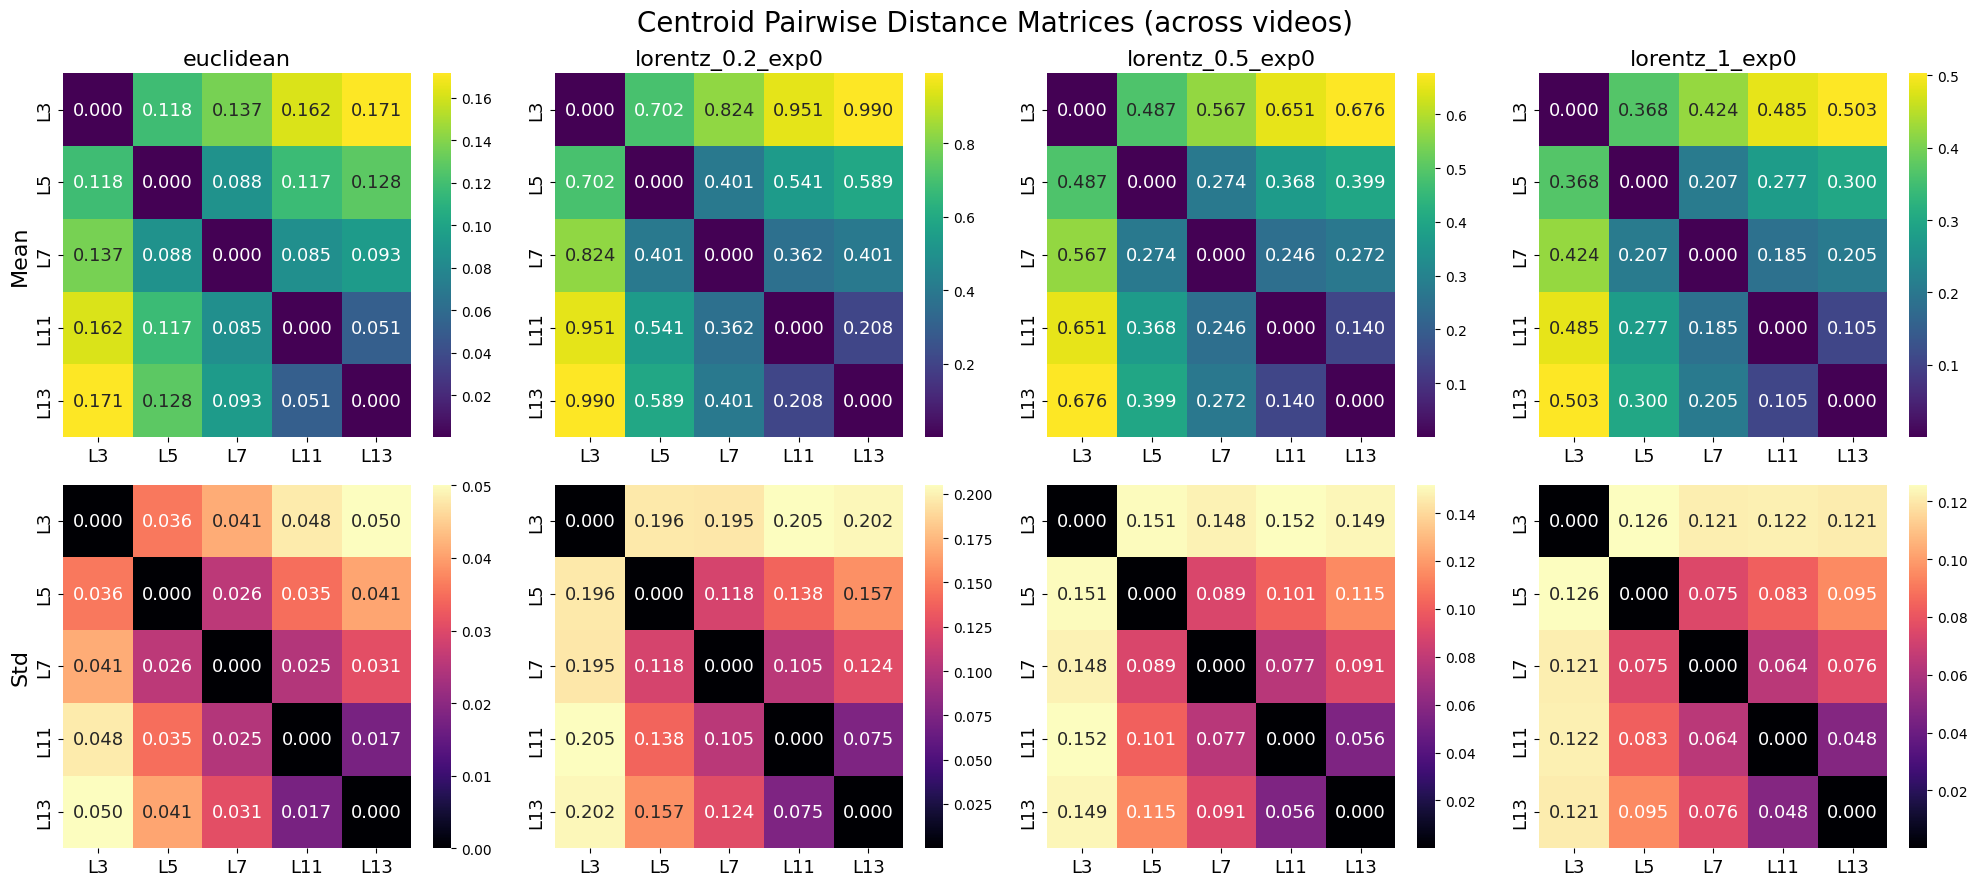

In [14]:
manifolds = sorted(set(
    m for v in distances_info.values() for m in v.keys()
))
level_labels = ["L3", "L5", "L7", "L11", "L13"]
# level_labels = ["L3", "L5", "L7", "L11"]

fig, axes = plt.subplots(2, len(manifolds), figsize=(5 * len(manifolds), 9))

for col, manifold_name in enumerate(manifolds):
    matrices = [
        distances_info[v][manifold_name]["dist_matrix"]
        for v in distances_info if manifold_name in distances_info[v]
    ]
    stacked = torch.stack(matrices)  # (N_videos, 5, 5)
    mean_mat = stacked.mean(dim=0).numpy()
    std_mat = stacked.std(dim=0).numpy()

    sns.heatmap(mean_mat, annot=True, fmt=".3f", cmap="viridis",
                xticklabels=level_labels, yticklabels=level_labels,
                ax=axes[0, col], annot_kws={"size": 13})
    axes[0, col].set_title(manifold_name, fontsize=16)
    axes[0, col].tick_params(labelsize=13)

    sns.heatmap(std_mat, annot=True, fmt=".3f", cmap="magma",
                xticklabels=level_labels, yticklabels=level_labels,
                ax=axes[1, col], annot_kws={"size": 13})
    axes[1, col].tick_params(labelsize=13)

axes[0, 0].set_ylabel("Mean", fontsize=16)
axes[1, 0].set_ylabel("Std", fontsize=16)

plt.suptitle("Centroid Pairwise Distance Matrices (across videos)", fontsize=20)
plt.tight_layout()
save_path = os.path.join(data_dir, "centroid_dist_matrix_mean_std.pdf")
plt.savefig(save_path, bbox_inches="tight")
plt.show()


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

LEVELS = [3, 5, 7, 11, 13]
# LEVELS = [3, 5, 7, 11]
GROUPS = [(0,3), (3,8), (8,15), (15,26), (26,39)]
# GROUPS = [(0,3), (3,8), (8,15), (15,26)]

# Collect per-level distances for each reference point
# Keys: (manifold, reference, level) -> list of mean distances for that level
metrics_per_level = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for video_name, video_data in distances_info.items():
    for manifold_name, manifold_data in video_data.items():
        for ref_key in ["dists_mean", "dists_origin_mean", "dists_pseudo_mean"]:
            if ref_key in manifold_data:
                dists = manifold_data[ref_key]  # (5,) tensor — one per level centroid
                for i, level in enumerate(LEVELS):
                    metrics_per_level[manifold_name][ref_key][level].append(dists[i].item())

        # Also per-slot distances grouped by level
        for ref_key in ["dists", "dists_origin", "dists_pseudo"]:
            if ref_key in manifold_data:
                dists = manifold_data[ref_key]  # (39,) tensor — one per slot
                for i, (a, b) in enumerate(GROUPS):
                    level = LEVELS[i]
                    level_dists = dists[a:b]
                    metrics_per_level[manifold_name][ref_key][level].extend(level_dists.tolist())



In [16]:
# KEYS = ["dists_mean", "dists_origin_mean", "dists_pseudo_mean", "dists", "dists_origin", "dists_pseudo"]
# KEYS = ["dists_mean", "dists_origin_mean", "dists_pseudo_mean"]
KEYS = ["dists_origin_mean"]
for manifold_name in sorted(metrics_per_level.keys()):
    print(f"\n=== {manifold_name} ===")
    for ref_key in KEYS:
        if ref_key not in metrics_per_level[manifold_name]:
            continue
        print(f"  {ref_key}:")
        for level in LEVELS:
            vals = metrics_per_level[manifold_name][ref_key][level]
            if vals:
                t = torch.tensor(vals)
                print(f"    L{level:>2d}: mean={t.mean().item():.4f}, std={t.std().item():.4f}")



=== euclidean ===
  dists_origin_mean:
    L 3: mean=5.9950, std=0.1923
    L 5: mean=5.8348, std=0.1907
    L 7: mean=5.7756, std=0.1954
    L11: mean=5.7412, std=0.2050
    L13: mean=5.7377, std=0.2053

=== lorentz_0.2_exp0 ===
  dists_origin_mean:
    L 3: mean=3.4742, std=0.2197
    L 5: mean=3.1003, std=0.1621
    L 7: mean=2.9823, std=0.1457
    L11: mean=2.9056, std=0.1372
    L13: mean=2.8921, std=0.1394

=== lorentz_0.5_exp0 ===
  dists_origin_mean:
    L 3: mean=2.2506, std=0.1529
    L 5: mean=1.9941, std=0.1087
    L 7: mean=1.9135, std=0.0963
    L11: mean=1.8604, std=0.0908
    L13: mean=1.8512, std=0.0931

=== lorentz_1_exp0 ===
  dists_origin_mean:
    L 3: mean=1.5998, std=0.1079
    L 5: mean=1.4151, std=0.0766
    L 7: mean=1.3562, std=0.0676
    L11: mean=1.3170, std=0.0651
    L13: mean=1.3104, std=0.0676


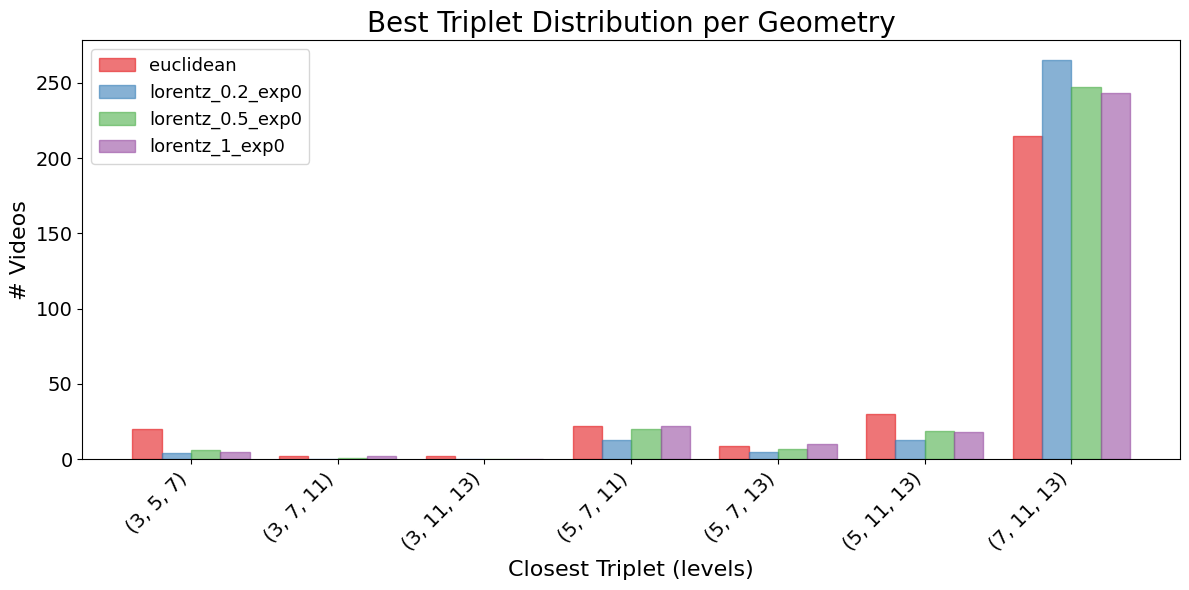

In [17]:
from collections import Counter

triplet_counts = defaultdict(Counter)

for video_name, video_data in distances_info.items():
    for manifold_name, manifold_data in video_data.items():
        triplet = manifold_data["best_triplet"]
        triplet_label = tuple(LEVELS[i] for i in triplet)
        triplet_counts[manifold_name][triplet_label] += 1

# Collect all unique triplets across manifolds
all_triplets = sorted(set(t for c in triplet_counts.values() for t in c.keys()))
labels = [str(t) for t in all_triplets]
x = np.arange(len(all_triplets))

MANIFOLD_COLORS = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628", "#f781bf"]
manifolds = sorted(triplet_counts.keys())

fig, ax = plt.subplots(figsize=(12, 6))
width = 0.8 / len(manifolds)

for idx, manifold_name in enumerate(manifolds):
    counts = [triplet_counts[manifold_name].get(t, 0) for t in all_triplets]
    color = MANIFOLD_COLORS[idx % len(MANIFOLD_COLORS)]
    ax.bar(x + idx * width, counts, width=width, color=color, alpha=0.6,
           edgecolor=color, label=manifold_name)

ax.set_xticks(x + width * (len(manifolds) - 1) / 2)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=14)
ax.set_xlabel("Closest Triplet (levels)", fontsize=16)
ax.set_ylabel("# Videos", fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.legend(fontsize=13)
ax.set_title("Best Triplet Distribution per Geometry", fontsize=20)

plt.tight_layout()
save_path = os.path.join(data_dir, "best_triplet_histogram.pdf")
plt.savefig(save_path, bbox_inches="tight")
plt.show()



In [18]:
import pandas as pd

LEVEL_COLORS = {3: "#ff7f00", 5: "#4daf4a", 7: "#377eb8", 11: "#984ea3", 13: "#a65628"}

# for ref_key in KEYS:
#     rows = []
#     for manifold_name in metrics_per_level:
#         if ref_key not in metrics_per_level[manifold_name]:
#             continue
#         for level in LEVELS:
#             for val in metrics_per_level[manifold_name][ref_key][level]:
#                 rows.append({"Manifold": manifold_name, "Distance": val})

#     if not rows:
#         continue

#     df = pd.DataFrame(rows)
#     fig, ax = plt.subplots(figsize=(12, 6))
#     sns.violinplot(data=df, x="Manifold", y="Distance", inner="quart", ax=ax)
#     ax.set_title(f"{ref_key} — All Levels Combined")
#     plt.xticks(rotation=30)
#     plt.tight_layout()
#     save_path = os.path.join(data_dir, f"{ref_key}_violin_all_levels.pdf")
#     plt.savefig(save_path, bbox_inches="tight")
#     plt.show()


In [19]:
# for ref_key in KEYS:
#     rows = []
#     for manifold_name in metrics_per_level:
#         if ref_key not in metrics_per_level[manifold_name]:
#             continue
#         for level in LEVELS:
#             for val in metrics_per_level[manifold_name][ref_key][level]:
#                 rows.append({"Manifold": manifold_name, "Level": str(level), "Distance": val})

#     if not rows:
#         continue

#     df = pd.DataFrame(rows)
#     palette = {str(l): c for l, c in LEVEL_COLORS.items()}

#     fig, ax = plt.subplots(figsize=(14, 6))
#     sns.violinplot(data=df, x="Manifold", y="Distance", hue="Level",
#                    palette=palette, dodge=False, inner="quart", linewidth=1, ax=ax)
#     for collection in ax.collections:
#         collection.set_alpha(0.4)
#     ax.set_title(f"{ref_key} — Per Level", fontsize=18)
#     ax.set_xlabel("Manifold", fontsize=16)
#     ax.set_ylabel("Distance", fontsize=16)
#     ax.tick_params(labelsize=14)
#     ax.legend(fontsize=13, title="Level", title_fontsize=14)
#     plt.xticks(rotation=30)
#     plt.tight_layout()
#     save_path = os.path.join(data_dir, f"{ref_key}_violin_per_level.pdf")
#     plt.savefig(save_path, bbox_inches="tight")
#     plt.show()


In [20]:
from scipy.stats import gaussian_kde

def kde_overlap(data1, data2, n_points=1000):
    """Jaccard-like overlap: intersection / union. Returns value in [0, 1]."""
    if len(data1) < 2 or len(data2) < 2:
        return float('0.0')
    if np.std(data1) < 1e-10 or np.std(data2) < 1e-10:
        return float('0.0')
    try:
        all_data = np.concatenate([data1, data2])
        xmin = all_data.min() - 0.1 * np.ptp(all_data)
        xmax = all_data.max() + 0.1 * np.ptp(all_data)
        x = np.linspace(xmin, xmax, n_points)
        kde1 = gaussian_kde(data1)(x)
        kde2 = gaussian_kde(data2)(x)
        kde1 /= np.trapz(kde1, x)
        kde2 /= np.trapz(kde2, x)
        intersection = np.trapz(np.minimum(kde1, kde2), x)
        union = np.trapz(np.maximum(kde1, kde2), x)
        return intersection / union if union > 0 else float('0.0')
    except np.linalg.LinAlgError:
        return float('0.0')



# Compute all pairwise overlaps: overlap_scores[ref_key][manifold][(l1, l2)] = score
overlap_scores = {}

for ref_key in KEYS:
    overlap_scores[ref_key] = {}
    for manifold_name in metrics_per_level:
        if ref_key not in metrics_per_level[manifold_name]:
            continue
        overlap_scores[ref_key][manifold_name] = {}
        for li, l1 in enumerate(LEVELS):
            for l2 in LEVELS[li+1:]:
                d1 = np.array(metrics_per_level[manifold_name][ref_key][l1])
                d2 = np.array(metrics_per_level[manifold_name][ref_key][l2])
                overlap_scores[ref_key][manifold_name][(l1, l2)] = kde_overlap(d1, d2)

# Print full overlap matrix per manifold
for ref_key in KEYS:
    print(f"\n=== {ref_key} — All Pairwise Overlaps ===")
    for manifold_name in sorted(overlap_scores[ref_key].keys()):
        print(f"\n  {manifold_name}:")
        for (l1, l2), ov in sorted(overlap_scores[ref_key][manifold_name].items()):
            print(f"    L{l1}-L{l2}: {ov:.3f}")



=== dists_origin_mean — All Pairwise Overlaps ===

  euclidean:
    L3-L5: 0.503
    L3-L7: 0.395
    L3-L11: 0.348
    L3-L13: 0.334
    L5-L7: 0.759
    L5-L11: 0.661
    L5-L13: 0.636
    L7-L11: 0.833
    L7-L13: 0.821
    L11-L13: 0.940

  lorentz_0.2_exp0:
    L3-L5: 0.200
    L3-L7: 0.096
    L3-L11: 0.066
    L3-L13: 0.063
    L5-L7: 0.540
    L5-L11: 0.332
    L5-L13: 0.317
    L7-L11: 0.628
    L7-L13: 0.574
    L11-L13: 0.868

  lorentz_0.5_exp0:
    L3-L5: 0.199
    L3-L7: 0.095
    L3-L11: 0.066
    L3-L13: 0.064
    L5-L7: 0.526
    L5-L11: 0.316
    L5-L13: 0.302
    L7-L11: 0.610
    L7-L13: 0.554
    L11-L13: 0.862

  lorentz_1_exp0:
    L3-L5: 0.192
    L3-L7: 0.090
    L3-L11: 0.063
    L3-L13: 0.062
    L5-L7: 0.514
    L5-L11: 0.305
    L5-L13: 0.292
    L7-L11: 0.598
    L7-L13: 0.545
    L11-L13: 0.858


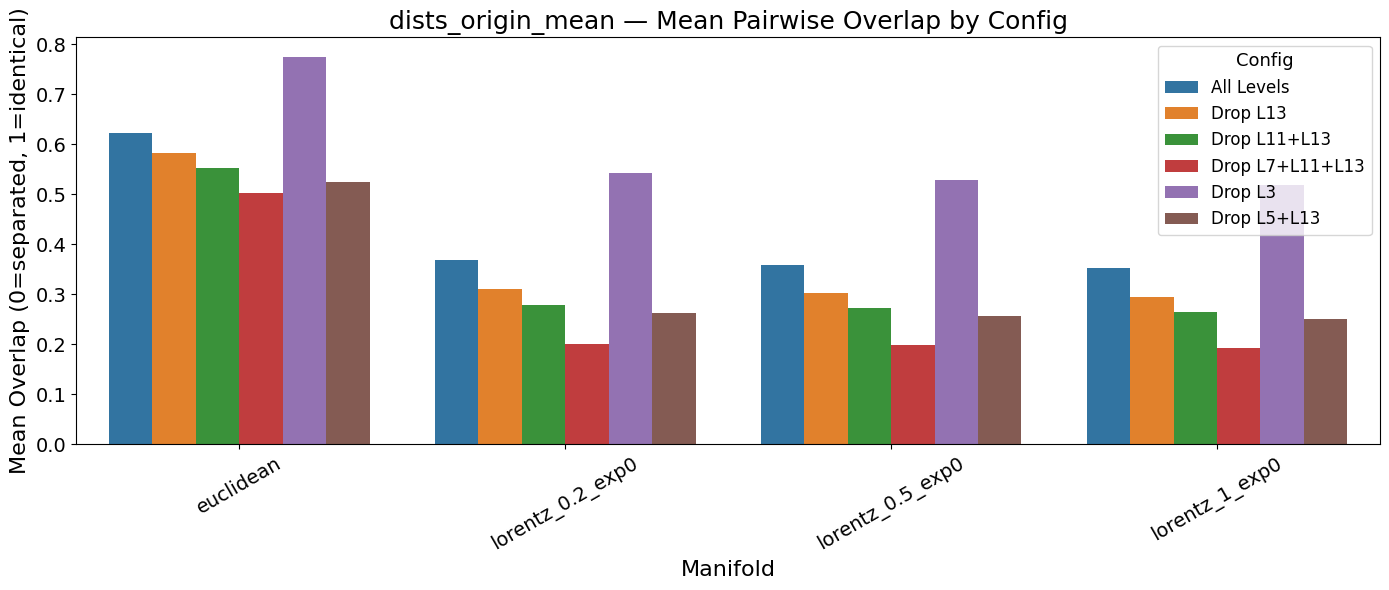

In [21]:
import pandas as pd

DROP_CONFIGS = [
    (LEVELS,              "All Levels"),
    ([3, 5, 7, 11],      "Drop L13"),
    ([3, 5, 7],           "Drop L11+L13"),
    ([3, 5],              "Drop L7+L11+L13"),
    ([5, 7, 11, 13],     "Drop L3"),
    ([3, 7, 11],         "Drop L5+L13"),
]

for ref_key in KEYS:
    rows = []
    for keep_levels, drop_label in DROP_CONFIGS:
        for manifold_name in sorted(overlap_scores[ref_key].keys()):
            # Average overlap across all pairs within the kept levels
            pair_overlaps = [
                overlap_scores[ref_key][manifold_name][(l1, l2)]
                for li, l1 in enumerate(keep_levels)
                for l2 in keep_levels[li+1:]
                if (l1, l2) in overlap_scores[ref_key][manifold_name]
            ]
            if pair_overlaps:
                rows.append({
                    "Config": drop_label,
                    "Manifold": manifold_name,
                    "Mean Overlap": np.nanmean(pair_overlaps),
                })

    agg_df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(data=agg_df, x="Manifold", y="Mean Overlap", hue="Config", ax=ax)
    ax.set_title(f"{ref_key} — Mean Pairwise Overlap by Config", fontsize=18)
    ax.set_xlabel("Manifold", fontsize=16)
    ax.set_ylabel("Mean Overlap (0=separated, 1=identical)", fontsize=16)
    ax.tick_params(labelsize=14)
    ax.legend(fontsize=12, title="Config", title_fontsize=13)
    plt.xticks(rotation=30)
    plt.tight_layout()
    save_path = os.path.join(data_dir, f"{ref_key}_overlap_by_config.pdf")
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()


In [22]:
def short_name(manifold_name):
    if manifold_name == "euclidean":
        return "Euclidean"
    if manifold_name.startswith("lorentz_"):
        c = manifold_name.split("_")[1]
        return f"Lorentz({c})"
    return manifold_name

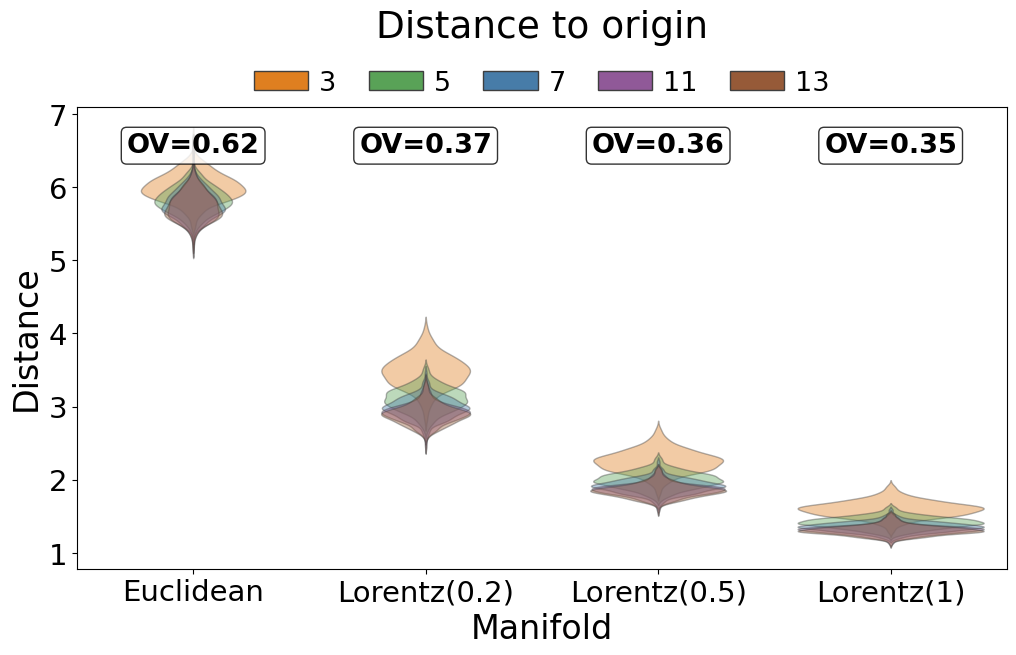

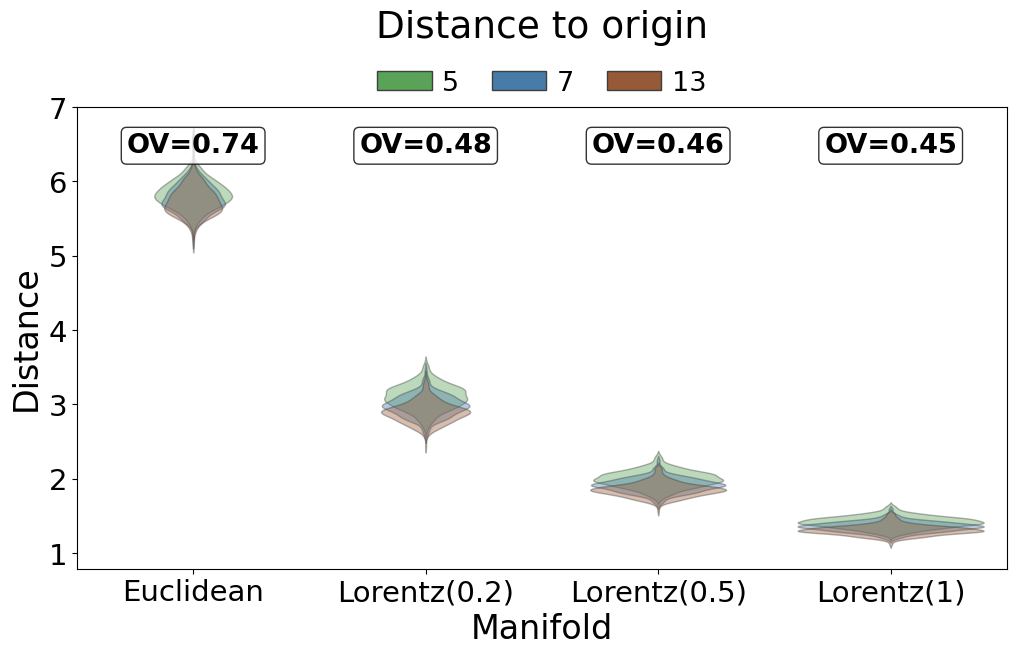

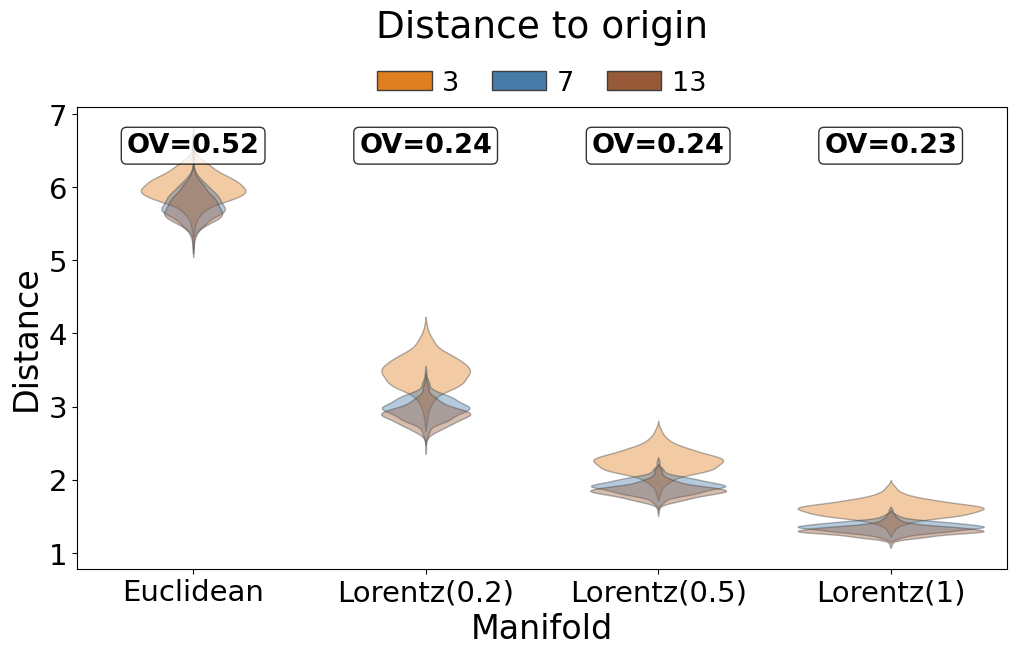

In [23]:
scale = 1.5

DROP_CONFIGS = [
    ([3, 5, 7, 11, 13], "All Levels"),
    # ([3, 5, 7, 11],    "Drop L13"),
    # ([3, 7, 11],         "Drop L5+L13"),
    # ([3, 5],            "Drop L7+L11+L13"),
    ([5, 7, 13],   "Drop L3+L11"),
    ([3, 7, 13],       "Drop L5+L11"),
    # ([3, 5, 7, 11],   "Drop L13"),
]
for ref_key in KEYS:
    for keep_levels, drop_label in DROP_CONFIGS:

        title = " ".join(w.capitalize() for w in ref_key.split("_"))
        if ref_key == "dists_origin_mean":
            title = "Distance to origin"
        else:
            title = "Distance to root"

        # --- Combined violin ---
        rows = []
        for manifold_name in metrics_per_level:
            if ref_key not in metrics_per_level[manifold_name]:
                continue
            for level in keep_levels:
                for val in metrics_per_level[manifold_name][ref_key][level]:
                    rows.append({"Manifold": short_name(manifold_name), "Distance": val})

        if not rows:
            continue

        df = pd.DataFrame(rows)
        # fig, ax = plt.subplots(figsize=(12, 6))
        # sns.violinplot(data=df, x="Manifold", y="Distance", inner=None, ax=ax)
        # ax.set_title(f"{title}", fontsize=scale*18)
        # ax.set_xlabel("Manifold", fontsize=scale*16)
        # ax.set_ylabel("Distance", fontsize=scale*16)
        # ax.tick_params(labelsize=scale*14)
        # plt.tight_layout()
        safe_label = drop_label.replace(" ", "_").replace("+", "_")
        save_path = os.path.join(data_dir, f"{ref_key}_violin_{safe_label}.pdf")
        # plt.savefig(save_path, bbox_inches="tight")
        # plt.show()

        # --- Overlapping per-level violin ---
        rows_level = []
        for manifold_name in metrics_per_level:
            if ref_key not in metrics_per_level[manifold_name]:
                continue
            for level in keep_levels:
                for val in metrics_per_level[manifold_name][ref_key][level]:
                    rows_level.append({"Manifold": short_name(manifold_name), "Level": str(level), "Distance": val})

        df_level = pd.DataFrame(rows_level)
        palette = {str(l): c for l, c in LEVEL_COLORS.items() if l in keep_levels}

        # Compute mean overlap for each manifold using precomputed scores
        manifold_overlaps = {}
        for manifold_name in sorted(metrics_per_level.keys()):
            if ref_key not in overlap_scores or manifold_name not in overlap_scores[ref_key]:
                continue
            pair_overlaps = [
                overlap_scores[ref_key][manifold_name][(l1, l2)]
                for li, l1 in enumerate(keep_levels)
                for l2 in keep_levels[li+1:]
                if (l1, l2) in overlap_scores[ref_key][manifold_name]
            ]
            if pair_overlaps:
                manifold_overlaps[manifold_name] = np.nanmean(pair_overlaps)

        fig, ax = plt.subplots(figsize=(12, 6))
        sns.violinplot(data=df_level, x="Manifold", y="Distance", hue="Level",
                       palette=palette, dodge=False, inner=None, linewidth=1, ax=ax)
        for collection in ax.collections:
            collection.set_alpha(0.4)

        # Annotate overlap score on top of each manifold's violin
        manifold_names_sorted = sorted(metrics_per_level.keys())
        for i, manifold_name in enumerate(manifold_names_sorted):
            if manifold_name in manifold_overlaps:
                ov = manifold_overlaps[manifold_name]
                y_top = ax.get_ylim()[1]
                ax.text(i, y_top * 0.95, f"OV={ov:.2f}",
                        ha="center", va="top", fontsize=scale*13, fontweight="bold",
                        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

        # ax.set_title(f"{title}", fontsize=scale*18)
        ax.set_xlabel("Manifold", fontsize=scale*16)
        ax.set_ylabel("Distance", fontsize=scale*16)
        ax.tick_params(labelsize=scale*14)
        ax.legend(
            fontsize=scale*13,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.97),
            ncol=len(ax.get_legend_handles_labels()[1]),
            frameon=False,
            columnspacing=1.2,
            handletextpad=0.4,
        )

        ax.set_title(f"{title}", fontsize=scale*18, pad=50)
        save_path = os.path.join(data_dir, f"{ref_key}_violin_{safe_label}_per_level.pdf")
        plt.savefig(save_path, bbox_inches="tight")
        plt.show()


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Collect hierarchy distances
hierarchy_dists = defaultdict(lambda: defaultdict(dict))

for video_name, video_data in distances_info.items():
    for manifold_name, manifold_data in video_data.items():
        for prefix in PREFIXES:
            for level in LEVELS:
                key = f"{prefix}_{level}"
                if key in manifold_data and isinstance(manifold_data[key], torch.Tensor):
                    if level not in hierarchy_dists[manifold_name][prefix]:
                        hierarchy_dists[manifold_name][prefix][level] = []
                    hierarchy_dists[manifold_name][prefix][level].append(manifold_data[key].item())




NameError: name 'PREFIXES' is not defined

In [ ]:
import os
for prefix in PREFIXES:

    rows = []

    for manifold_name in hierarchy_dists:
        if prefix not in hierarchy_dists[manifold_name]:
            continue

        for level in LEVELS:
            if level not in hierarchy_dists[manifold_name][prefix]:
                continue

            for val in hierarchy_dists[manifold_name][prefix][level]:
                rows.append({
                    "Manifold": manifold_name,
                    "Level": str(level),
                    "Distance": val
                })

    if not rows:
        continue

    df = pd.DataFrame(rows)

    plt.figure(figsize=(10,6))

    ax = sns.violinplot(
        data=df,
        x="Manifold",
        y="Distance",
        hue="Level",
        palette=palette,
        dodge=False,
        inner="quart",
        linewidth=1
    )

    # Set alpha for the violin bodies
    for collection in ax.collections:
        collection.set_alpha(0.5)

    plt.title(prefix)
    plt.xticks(rotation=45)
    plt.tight_layout()

    # save figure before show (show clears the figure)
    save_path = os.path.join(data_dir, f"{prefix}_violin.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


In [ ]:
# Free plotting intermediates before heavy computation
import gc
del dist_origin_per_manifold, hierarchy_dists
gc.collect()
print(f"Memory freed. Ready for embedding computation.")

In [ ]:
import sys
import numpy as np
from sklearn.manifold import TSNE
import umap
import gc

sys.path.insert(0, "/home/alexpv/Default_Folder/notes/phd/1-projects/CO-SNE")
from htsne_impl import TSNE as hTSNE
import hyptorch.pmath as pmath

LEVELS = [3, 5, 7, 11, 13]
LEVEL_RANGES = [(0, 3), (3, 8), (8, 15), (15, 26), (26, 39)]
LEVEL_COLORS = ["#ff7f00", "#4daf4a", "#377eb8", "#984ea3", "#a65628"]

# Collect all slot vectors per manifold and assign level labels
vectors_per_manifold = {}
level_labels = None
n_videos = len(embeddings_info)

for video_name, video_data in embeddings_info.items():
    for manifold_name, manifold_data in video_data.items():
        if manifold_name == "raw":
            continue
        # Use float32 instead of float64 to halve memory
        vectors = torch.cat([v for v in manifold_data.values()], dim=0).float()
        if manifold_name not in vectors_per_manifold:
            vectors_per_manifold[manifold_name] = []
        vectors_per_manifold[manifold_name].append(vectors)

        # Build labels once (same for all manifolds)
        if level_labels is None:
            labels_one_video = []
            for level, (start, end) in zip(LEVELS, LEVEL_RANGES):
                labels_one_video.extend([level] * (end - start))
            level_labels = labels_one_video

# Stack across videos as numpy float32
for manifold_name in vectors_per_manifold:
    vectors_per_manifold[manifold_name] = torch.cat(vectors_per_manifold[manifold_name], dim=0).numpy()

# Free embeddings_info — biggest memory hog, no longer needed
# (re-run the loading cell if you need it again)
del embeddings_info
gc.collect()

# Repeat labels for all videos
all_labels = np.array(level_labels * n_videos)
label_to_color = {level: color for level, color in zip(LEVELS, LEVEL_COLORS)}
all_colors = [label_to_color[l] for l in all_labels]

print(f"Vectors per manifold: {[(k, v.shape, v.dtype) for k, v in vectors_per_manifold.items()]}")
print(f"Labels shape: {all_labels.shape}, unique: {np.unique(all_labels)}")

Vectors per manifold: [('euclidean', (11700, 128), dtype('float32')), ('lorentz_0.2_exp0', (11700, 129), dtype('float32')), ('lorentz_0.5_exp0', (11700, 129), dtype('float32')), ('lorentz_1_exp0', (11700, 129), dtype('float32'))]
Labels shape: (11700,), unique: [ 3  5  7 11 13]


In [ ]:
import gc
import importlib
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="umap")

# Force reload CO-SNE to pick up the patched htsne_impl
import htsne_impl; importlib.reload(htsne_impl)
from htsne_impl import TSNE as hTSNE

def lorentz_to_poincare(x):
    """Convert Lorentz model vectors to Poincaré ball coordinates."""
    return x[..., 1:] / (1 + x[..., 0:1])

def plot_manifold_embeddings(manifold_name, emb_dict, sub_labels, LEVELS, LEVEL_COLORS):
    """Quick inline plot for a single manifold: 1 row x 3 cols (t-SNE, UMAP, CO-SNE)."""
    methods = ["tsne", "umap", "cosne"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for j, method in enumerate(methods):
        ax = axes[j]
        emb = emb_dict.get(method)
        if emb is None:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center", fontsize=14, transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
        else:
            for level, color in zip(LEVELS, LEVEL_COLORS):
                mask = sub_labels == level
                ax.scatter(emb[mask, 0], emb[mask, 1], c=color, s=10, alpha=0.5, label=f"lvl {level}")
            if method == "cosne":
                circle = plt.Circle((0, 0), 1, color="black", fill=False, linewidth=0.5)
                ax.add_patch(circle)
                ax.set_aspect("equal")
        ax.set_title(f"{method.upper()}", fontsize=11)
    fig.suptitle(manifold_name, fontsize=13)
    axes[0].legend(fontsize=7, markerscale=2)
    plt.tight_layout()
    plt.show()

# Subsample and free full vectors
MAX_VIDEOS = 50
SLOTS_PER_VIDEO = 39
n_sub = MAX_VIDEOS * SLOTS_PER_VIDEO
sub_labels = all_labels[:n_sub]
sub_colors = all_colors[:n_sub]

vectors_sub = {}
for manifold_name, vecs in vectors_per_manifold.items():
    vectors_sub[manifold_name] = vecs[:n_sub]
del vectors_per_manifold
gc.collect()

embeddings_2d = {}
print(f"Using {MAX_VIDEOS} videos, {n_sub} points per manifold")
print(f"Manifolds to process: {list(vectors_sub.keys())}")

Using 50 videos, 1950 points per manifold
Manifolds to process: ['euclidean', 'lorentz_0.2_exp0', 'lorentz_0.5_exp0', 'lorentz_1_exp0']


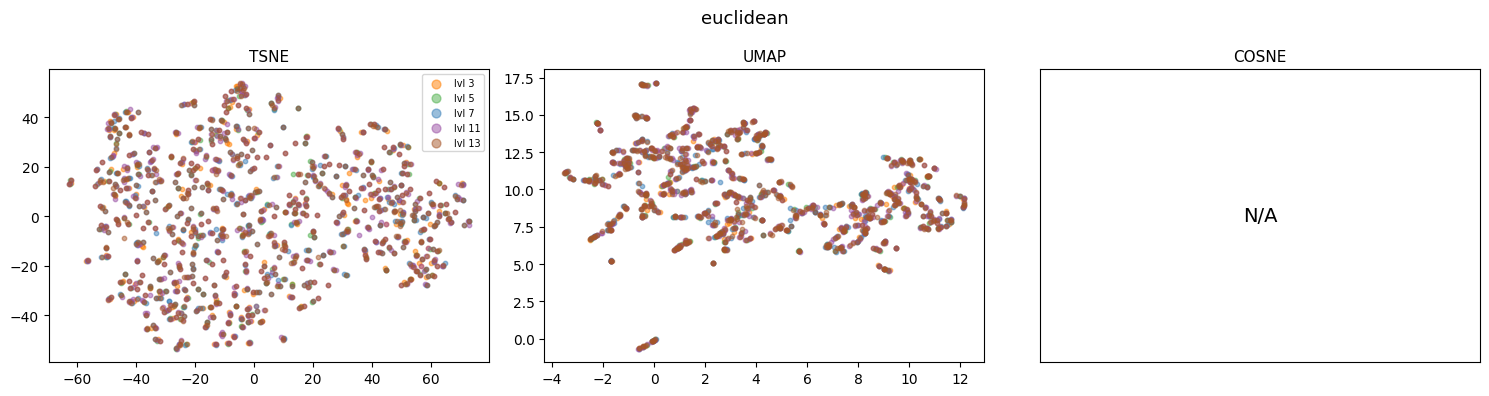

euclidean done.


In [ ]:
# --- Euclidean ---
manifold_name = "euclidean"
vecs = vectors_sub.pop(manifold_name)

tsne = TSNE(n_components=2, metric="euclidean", random_state=42, perplexity=30)
emb_tsne = tsne.fit_transform(vecs); del tsne

umap_model = umap.UMAP(n_components=2, metric="euclidean", random_state=42)
emb_umap = umap_model.fit_transform(vecs); del umap_model

embeddings_2d[manifold_name] = {"tsne": emb_tsne, "umap": emb_umap, "cosne": None}
del vecs; gc.collect()

plot_manifold_embeddings(manifold_name, embeddings_2d[manifold_name], sub_labels, LEVELS, LEVEL_COLORS)
print(f"{manifold_name} done.")

In [ ]:
# --- Sphere ---
manifold_name = "sphere"
vecs = vectors_sub.pop(manifold_name)

tsne = TSNE(n_components=2, metric="cosine", init="random", random_state=42, perplexity=30)
emb_tsne = tsne.fit_transform(vecs); del tsne

umap_model = umap.UMAP(n_components=2, metric="cosine", random_state=42)
emb_umap = umap_model.fit_transform(vecs); del umap_model

embeddings_2d[manifold_name] = {"tsne": emb_tsne, "umap": emb_umap, "cosne": None}
del vecs; gc.collect()

plot_manifold_embeddings(manifold_name, embeddings_2d[manifold_name], sub_labels, LEVELS, LEVEL_COLORS)
print(f"{manifold_name} done.")

KeyError: 'sphere'

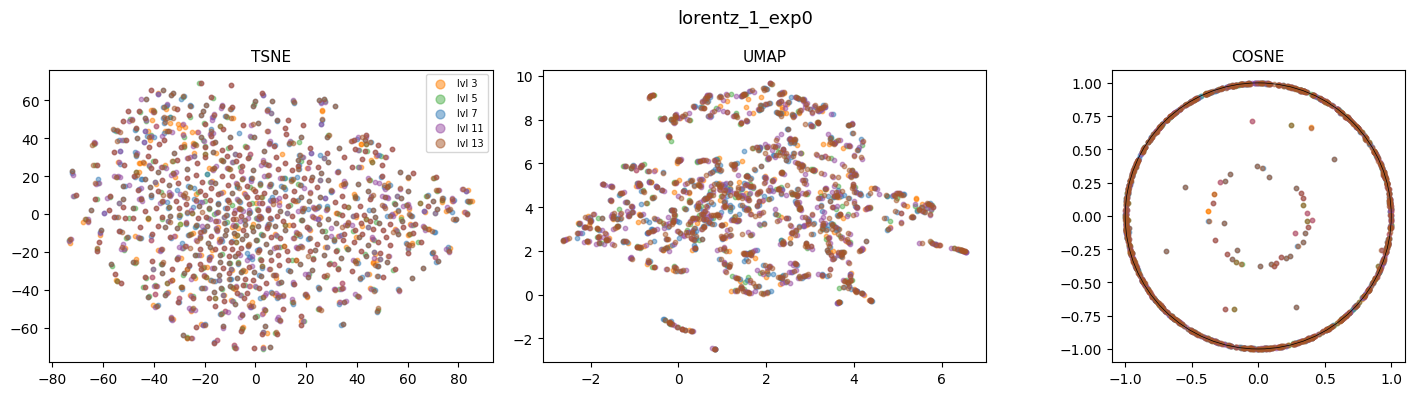

lorentz_1_exp0 done.


In [ ]:
# --- Lorentz exp0 ---
manifold_name = "lorentz_1_exp0"
vecs = vectors_sub.pop(manifold_name)
c_val = float(manifold_name.split("_")[1])
vecs_t = torch.from_numpy(vecs)

# Pairwise hyperbolic distances — in-place ops to reduce peak memory
inner = -vecs_t[:, 0:1] * vecs_t[:, 0:1].T + vecs_t[:, 1:] @ vecs_t[:, 1:].T
inner.mul_(-c_val).clamp_(min=1.0)
dist_matrix = torch.acosh(inner).div_(np.sqrt(c_val)).numpy()
del inner; gc.collect()
np.fill_diagonal(dist_matrix, 0.0)

# t-SNE
tsne = TSNE(n_components=2, metric="precomputed", init="random", random_state=42, perplexity=30)
emb_tsne = tsne.fit_transform(dist_matrix); del tsne

# UMAP
umap_model = umap.UMAP(n_components=2, metric="precomputed", random_state=42)
emb_umap = umap_model.fit_transform(dist_matrix)
del umap_model, dist_matrix; gc.collect()

# CO-SNE
poincare_vecs = lorentz_to_poincare(vecs_t)
del vecs_t
poincare_dists = pmath.dist_matrix(poincare_vecs, poincare_vecs, c=torch.tensor(c_val)).numpy()
np.fill_diagonal(poincare_dists, 0.0)
cosne = hTSNE(
    n_components=2, metric="precomputed", method="exact",
    learning_rate_for_h_loss=0.1, student_t_gamma=0.1,
    learning_rate=5.0, n_iter=1000, perplexity=30,
    early_exaggeration=1.0, random_state=42, verbose=0,
    square_distances=True,
)
emb_cosne = cosne.fit_transform(poincare_dists, poincare_vecs.numpy())
del cosne, poincare_dists, poincare_vecs; gc.collect()

embeddings_2d[manifold_name] = {"tsne": emb_tsne, "umap": emb_umap, "cosne": emb_cosne}
del vecs; gc.collect()

plot_manifold_embeddings(manifold_name, embeddings_2d[manifold_name], sub_labels, LEVELS, LEVEL_COLORS)
print(f"{manifold_name} done.")

In [ ]:
# --- Sphere stereographic ---
manifold_name = "sphere_estereographic"
vecs = vectors_sub.pop(manifold_name)

tsne = TSNE(n_components=2, metric="cosine", init="random", random_state=42, perplexity=30)
emb_tsne = tsne.fit_transform(vecs); del tsne

umap_model = umap.UMAP(n_components=2, metric="cosine", random_state=42)
emb_umap = umap_model.fit_transform(vecs); del umap_model

embeddings_2d[manifold_name] = {"tsne": emb_tsne, "umap": emb_umap, "cosne": None}
del vecs; gc.collect()

plot_manifold_embeddings(manifold_name, embeddings_2d[manifold_name], sub_labels, LEVELS, LEVEL_COLORS)
print(f"{manifold_name} done.")

In [ ]:
# --- Lorentz projx restricted ---
manifold_name = "lorentz_1_projx_restricted"
vecs = vectors_sub.pop(manifold_name)
c_val = float(manifold_name.split("_")[1])
vecs_t = torch.from_numpy(vecs)

# Pairwise hyperbolic distances — in-place ops to reduce peak memory
inner = -vecs_t[:, 0:1] * vecs_t[:, 0:1].T + vecs_t[:, 1:] @ vecs_t[:, 1:].T
inner.mul_(-c_val).clamp_(min=1.0)
dist_matrix = torch.acosh(inner).div_(np.sqrt(c_val)).numpy()
del inner; gc.collect()
np.fill_diagonal(dist_matrix, 0.0)

# t-SNE
tsne = TSNE(n_components=2, metric="precomputed", init="random", random_state=42, perplexity=30)
emb_tsne = tsne.fit_transform(dist_matrix); del tsne

# UMAP
umap_model = umap.UMAP(n_components=2, metric="precomputed", random_state=42)
emb_umap = umap_model.fit_transform(dist_matrix)
del umap_model, dist_matrix; gc.collect()

# CO-SNE
poincare_vecs = lorentz_to_poincare(vecs_t)
del vecs_t
poincare_dists = pmath.dist_matrix(poincare_vecs, poincare_vecs, c=torch.tensor(c_val)).numpy()
np.fill_diagonal(poincare_dists, 0.0)
cosne = hTSNE(
    n_components=2, metric="precomputed", method="exact",
    learning_rate_for_h_loss=0.1, student_t_gamma=0.1,
    learning_rate=5.0, n_iter=1000, perplexity=30,
    early_exaggeration=1.0, random_state=42, verbose=0,
    square_distances=True,
)
emb_cosne = cosne.fit_transform(poincare_dists, poincare_vecs.numpy())
del cosne, poincare_dists, poincare_vecs; gc.collect()

embeddings_2d[manifold_name] = {"tsne": emb_tsne, "umap": emb_umap, "cosne": emb_cosne}
del vecs; gc.collect()

plot_manifold_embeddings(manifold_name, embeddings_2d[manifold_name], sub_labels, LEVELS, LEVEL_COLORS)
print(f"{manifold_name} done.")

In [ ]:
# Grid of subplots: rows = manifolds, cols = methods
methods = ["tsne", "umap", "cosne"]
manifold_names = sorted(embeddings_2d.keys())
n_rows = len(manifold_names)
n_cols = len(methods)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

for i, manifold_name in enumerate(manifold_names):
    for j, method in enumerate(methods):
        ax = axes[i, j]
        emb = embeddings_2d[manifold_name].get(method)
        if emb is None:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center", fontsize=14, transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            for k, (level, color) in enumerate(zip(LEVELS, LEVEL_COLORS)):
                mask = sub_labels == level
                ax.scatter(emb[mask, 0], emb[mask, 1], c=color, s=10, alpha=0.5, label=f"lvl {level}")
            if method == "cosne":
                circle = plt.Circle((0, 0), 1, color="black", fill=False, linewidth=0.5)
                ax.add_patch(circle)
                ax.set_aspect("equal")
        if i == 0:
            ax.set_title(method.upper(), fontsize=13)
        if j == 0:
            ax.set_ylabel(manifold_name, fontsize=10)

# Single legend at bottom
handles, labels_legend = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_legend, loc="lower center", ncol=5, fontsize=10, markerscale=3)
plt.tight_layout(rect=[0, 0.03, 1, 1])

# Save figure before show (show clears the figure)
save_path = os.path.join(data_dir, f"latent_space_visualizations.png")
fig.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Helper for interactive Plotly plots
import plotly.graph_objects as go
from IPython.display import display, HTML

def plot_manifold_interactive(manifold_name, embeddings_2d, sub_labels, LEVELS, LEVEL_COLORS):
    for method in ["tsne", "umap", "cosne"]:
        emb = embeddings_2d[manifold_name].get(method)
        if emb is None:
            continue

        fig = go.Figure()
        for level, color in zip(LEVELS, LEVEL_COLORS):
            mask = sub_labels == level
            fig.add_trace(go.Scattergl(
                x=emb[mask, 0], y=emb[mask, 1],
                mode="markers",
                marker=dict(size=7, color=color, opacity=0.6),
                name=f"level {level}",
            ))

        if method == "cosne":
            theta = np.linspace(0, 2 * np.pi, 200)
            fig.add_trace(go.Scatter(
                x=np.cos(theta), y=np.sin(theta),
                mode="lines", line=dict(color="black", width=1),
                showlegend=False,
            ))
            fig.update_yaxes(scaleanchor="x", scaleratio=1)

        fig.update_layout(
            title=dict(text=f"{manifold_name} — {method.upper()}"),
            width=700, height=600,
            hovermode="closest",
        )
        display(HTML(fig.to_html()))

# --- Euclidean ---
plot_manifold_interactive("euclidean", embeddings_2d, sub_labels, LEVELS, LEVEL_COLORS)

In [ ]:
# --- Sphere ---
plot_manifold_interactive("sphere", embeddings_2d, sub_labels, LEVELS, LEVEL_COLORS)

In [ ]:
# --- Lorentz exp0 ---
plot_manifold_interactive("lorentz_1_exp0", embeddings_2d, sub_labels, LEVELS, LEVEL_COLORS)

In [ ]:
# --- Sphere stereographic ---
plot_manifold_interactive("sphere_estereographic", embeddings_2d, sub_labels, LEVELS, LEVEL_COLORS)

In [ ]:
# --- Lorentz projx restricted ---
plot_manifold_interactive("lorentz_1_projx_restricted", embeddings_2d, sub_labels, LEVELS, LEVEL_COLORS)

# Trees
I can think of 5 ways to build the trees: 
1. Easy way: take level i+1 and compute the distance of the vectors in this level to the vectors in level i, assign to each vector the closer parent in this sense. Repeat this for each level. I call this Child-Parent Retrieval.

2. Heavy way: for each vector in the hierarchy connect it with the immediatly closer vector. Then consider the vector corresponding to 0 (the mean of the vectors at level 3) to be the root of the tree. 

3. Heavy way at origin: the same as before but considering root to be the origin of the space (this only applies to Euclidean and Lorentz variants).

4. Tree traversals: Start with the nodes at highest level: 13, find the geodesic connectinc the nodes with the origin, and build the tree with the nodes found along the geodesics --> in this case it is expected that some nodes will remain unconnected. (in this case 0 can also be either the mean of vectors at level 3 or the origin of the vector space in case of Euclidean and Lorentz variants).

5. Invers tree traverals: Same as before but in inverse order, what happens if we start with nodes at level 3 and fall towards the origin? We do this to see if, in case above fails, is because some invers hierarchy is learn in the latent space.